---

# Assessment 1 — Introduction to Deep Convolutional Neural Networks

## Deep Learning (COSC 2779 / 2792)

### Name: Sridhar Srinath (**Student ID: S4182099**)

---
## 1. Environment Setup

In [1]:
# Importing the necessary libraries used throughout the notebook
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# Use a GPU if one is available
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [3]:
# Fixed seed everywhere, so re-running this notebook gives the same result
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

---
## 2. Data Accessing and Inspecting

In [4]:
GESTURE_CLASSES = ["AllClear", "HaveCommand", "Hover", "Land", "LandingDirection",
                  "MoveAhead", "MoveDownward", "MoveToLeft", "MoveToRight",
                  "MoveUpward", "NotClear", "SlowDown", "WaveOff"]

NUM_CLASSES = len(GESTURE_CLASSES)
NUM_FRAMES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 16

DATA_ROOT = "./A1_data_2026/data_resized"

In [5]:
# Sanity check to see what's inside a folder
def peek_directory(root, max_items=15):
    if not os.path.isdir(root):
        print(f"'{root}' does not exist")
        return
    for name in sorted(os.listdir(root))[:max_items]:
        print(name)

peek_directory(DATA_ROOT)

.DS_Store
AllClear
HaveCommand
Hover
Land
LandingDirection
MoveAhead
MoveDownward
MoveToLeft
MoveToRight
MoveUpward
NotClear
SlowDown
WaveOff


In [6]:
def frame_number (filename):
    """Get the frame number from a filename like '..._instance5_3.png' —> 3.
    The frame number is always the last underscore-separated part."""
    name_without_extension = os.path.splitext(filename)[0]
    return int(name_without_extension.split("_")[-1])

In [7]:
def discover_dataset(root_dir, classes=GESTURE_CLASSES, expected_frames=NUM_FRAMES):
    """Walk root_dir/<class>/<subject>/<instance>/ and return a list of samples.
    Each sample is (frame_paths, class_index, subject_id)."""
    samples = []
    for class_index, class_name in enumerate(classes):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f"WARNING: class folder not found: {class_dir}")
            continue
        for subject in sorted(os.listdir(class_dir)):
            subject_dir = os.path.join(class_dir, subject)
            if not os.path.isdir(subject_dir):
                continue

            for instance in sorted(os.listdir(subject_dir)):
                instance_dir = os.path.join(subject_dir, instance)
                if not os.path.isdir(instance_dir):
                    continue

                filenames = [f for f in os.listdir(instance_dir) if not f.startswith(".")]
                filenames = sorted(filenames, key=frame_number)

                if len(filenames) != expected_frames:
                    print(f"WARNING: {instance_dir} has {len(filenames)} frames (expected {expected_frames}) -- skipping")
                    continue

                frame_paths = [os.path.join(instance_dir, f) for f in filenames]
                samples.append((frame_paths, class_index, subject))

    return samples

In [8]:
all_samples = discover_dataset(DATA_ROOT)
n_subjects = len(set(subject for _, _, subject in all_samples))
print(f"Discovered {len(all_samples)} instances across {NUM_CLASSES} classes, from {n_subjects} unique subjects.")

Discovered 1059 instances across 13 classes, from 11 unique subjects.


---
## 3. Class Distribution and Sample Instances

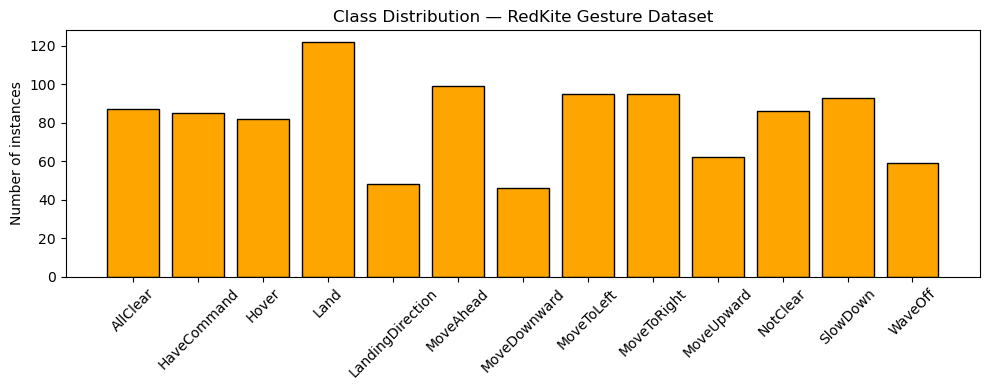

AllClear         87
HaveCommand      85
Hover            82
Land             122
LandingDirection 48
MoveAhead        99
MoveDownward     46
MoveToLeft       95
MoveToRight      95
MoveUpward       62
NotClear         86
SlowDown         93
WaveOff          59


In [9]:
labels_all = [label for _, label, _ in all_samples]
unique, counts = np.unique(labels_all, return_counts=True)

fig, ax = plt.subplots(figsize=(10,4))
ax.bar([GESTURE_CLASSES[u] for u in unique], counts, color='orange', edgecolor='black')
ax.set_title('Class Distribution — RedKite Gesture Dataset')
ax.set_ylabel('Number of instances')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

for u, c in zip(unique, counts):
    print(f'{GESTURE_CLASSES[u]:<16} {c}')

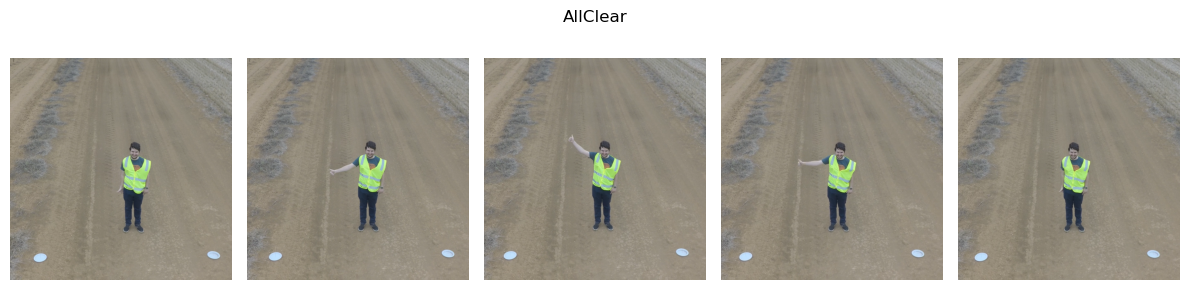

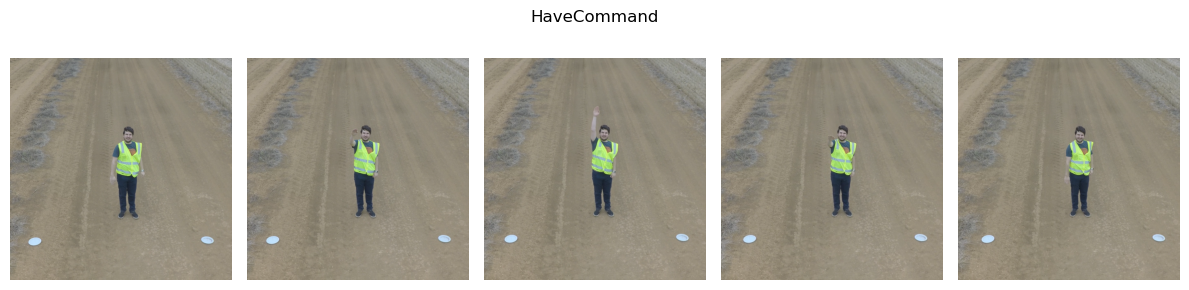

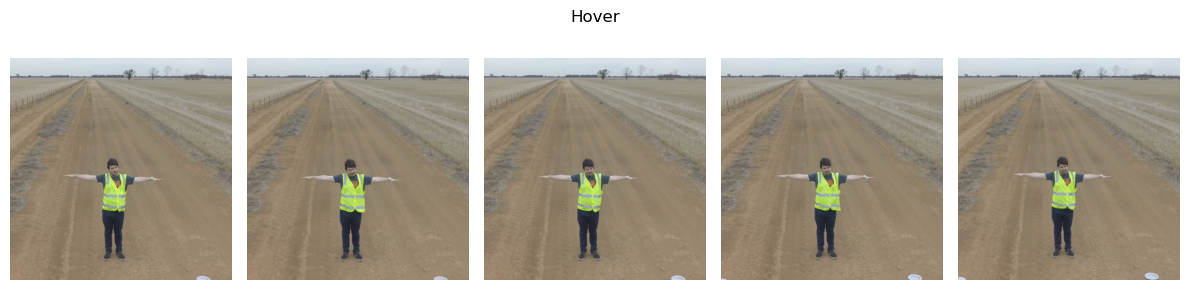

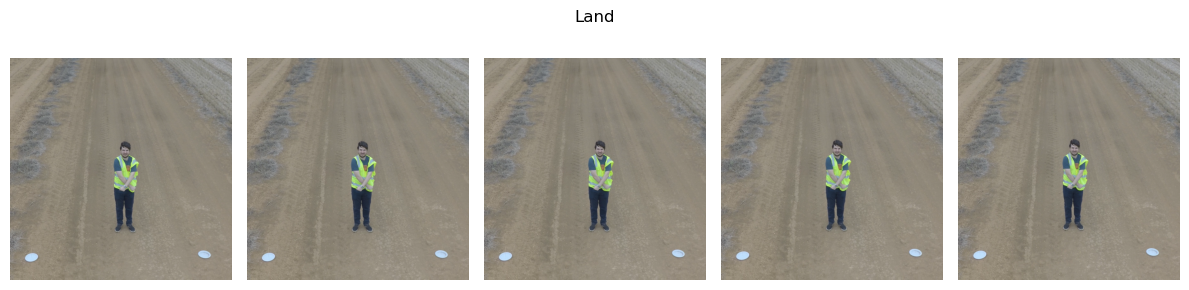

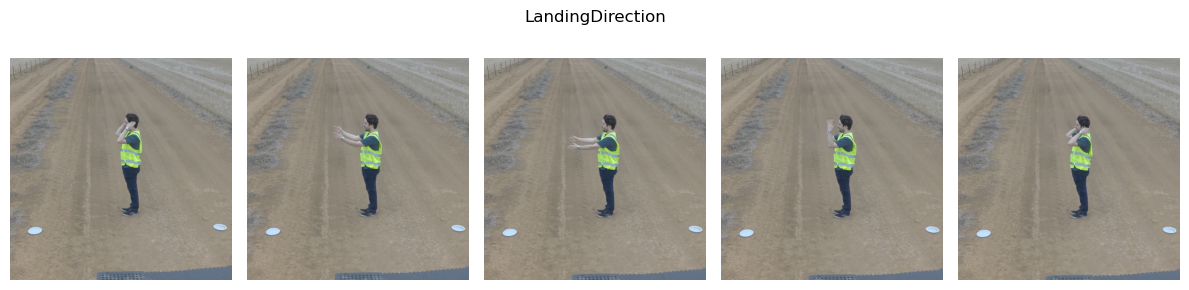

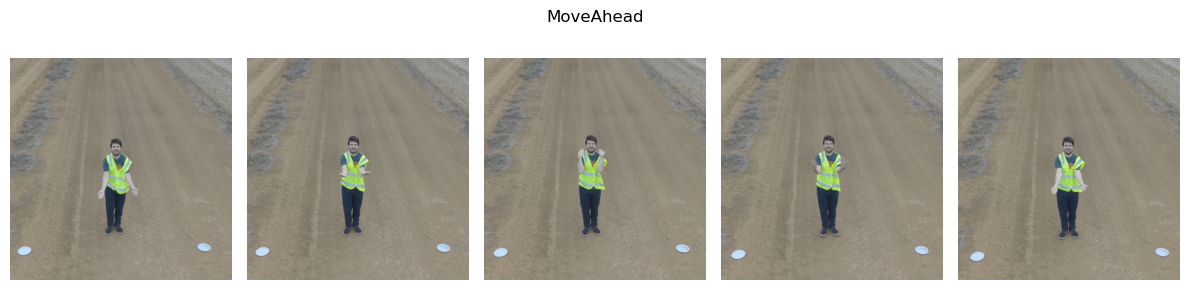

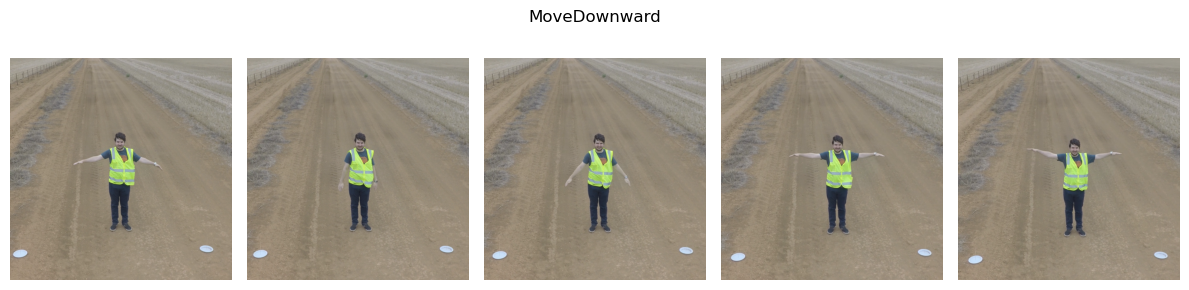

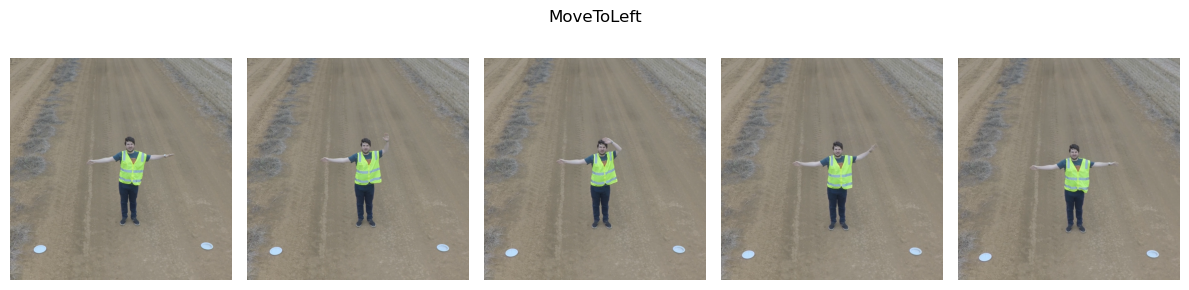

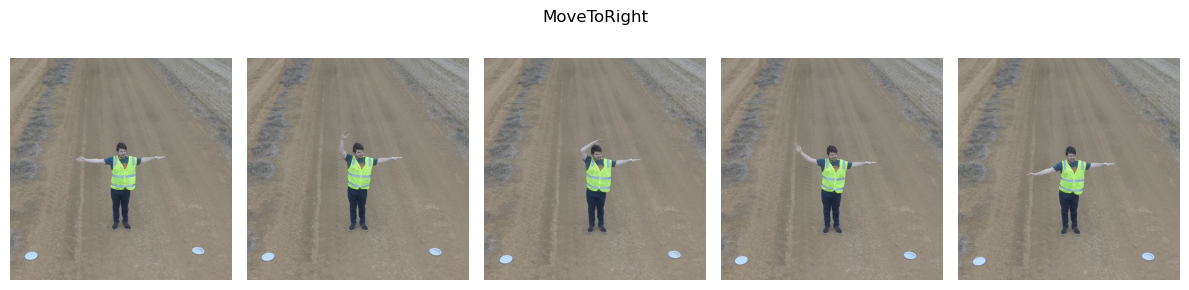

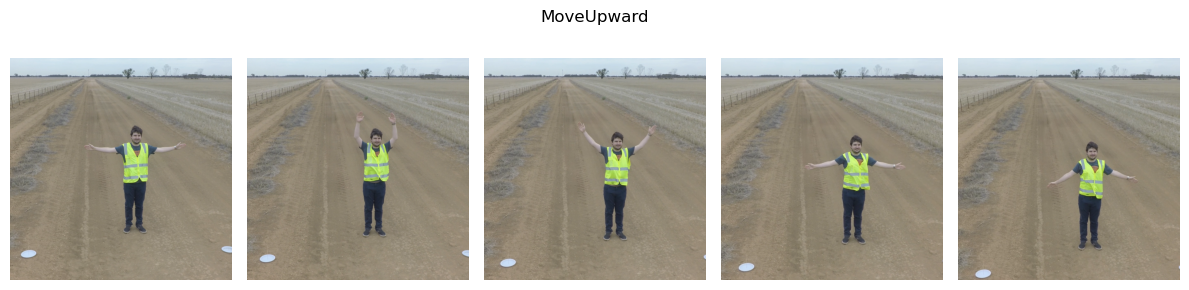

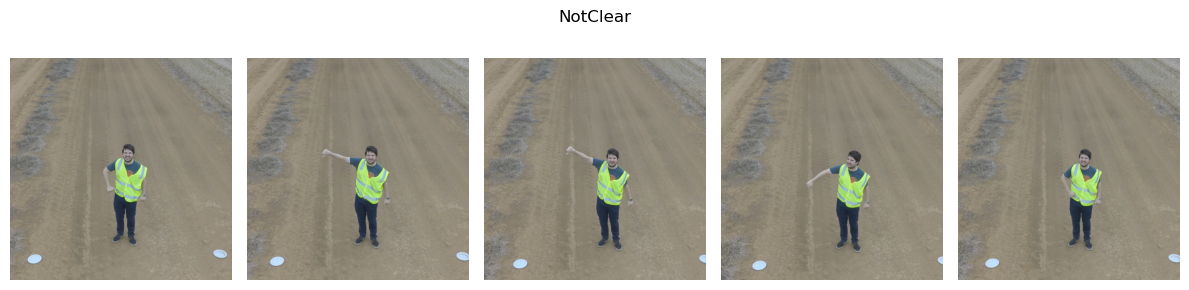

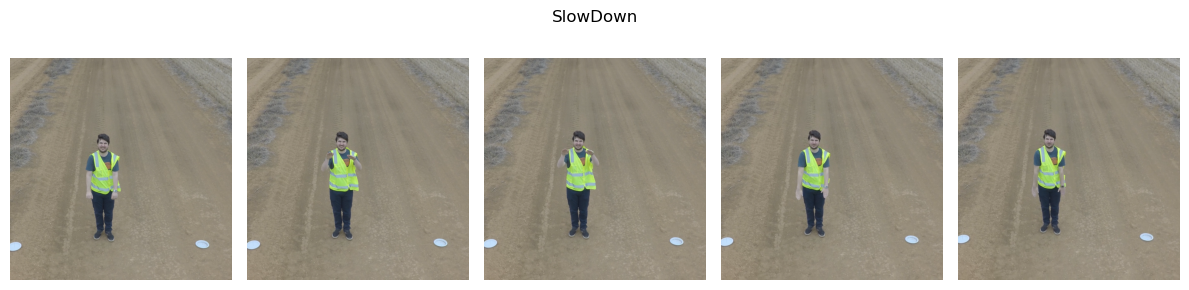

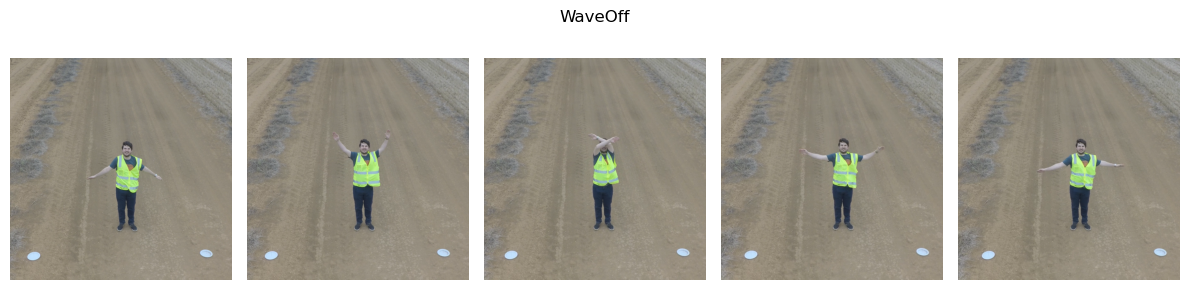

In [14]:
def show_instance(frame_paths, title=""):
    """Display the 5 frames of one instance side by side."""
    fig, axes = plt.subplots(1, len(frame_paths), figsize=(12,3))
    for ax, path in zip(axes, frame_paths):
        ax.imshow(Image.open(path).convert("RGB"))
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# Show one xample instance per class
sample_by_class = {}
for frames, label, _ in all_samples:
    sample_by_class.setdefault(label, frames)

for label, frames in list(sample_by_class.items())[:13]:
    show_instance(frames, title=GESTURE_CLASSES[label])

---
## 4. Subject-Level Train / Validation / Test Split

**Why split by subject, not by clip?** On demo day, the drone reads gestures from a client staff member who isn't in out training data at all. That's the real test of generalisation. If we split the 1059 instances randomly, the same person's clips could end up in both train and validation/test — the model could then partly succeed by recognising *who* is signalling, not just *what* they're signalling, which would make our reported accuracy overly optimistic.

So instead we split by **subject**: every one of a person's clips goes entirely into one split.

**Limitation to keep in mind:** with only 11 subjects, holding out 2 for testing means the final test accuracy really reflects 2 people's signalling style. A different pai of held-out subjects could give a noticeably different number — this single split is simple, but it is a high-variance estimate.

In [19]:
# All subjects, shuffles with a fixed seed so the split is reproducible
subjects = sorted(set(subject for _, _, subject in all_samples))
shuffled_subjects = subjects.copy()
random.Random(SEED).shuffle(shuffled_subjects)

N_TEST_SUBJECTS = 2
N_VAL_SUBJECTS = 2

test_subjects = set(shuffled_subjects[:N_TEST_SUBJECTS])
val_subjects = set(shuffled_subjects[N_TEST_SUBJECTS:N_TEST_SUBJECTS + N_VAL_SUBJECTS])
train_subjects = set(shuffled_subjects[N_TEST_SUBJECTS + N_VAL_SUBJECTS:])

train_samples = [s for s in all_samples if s[2] in train_subjects]
val_samples = [s for s in all_samples if s[2] in val_subjects]
test_samples = [s for s in all_samples if s[2] in test_subjects]

print(f"Train: {len(train_samples):4d} instances, subjects: {sorted(train_subjects)}")
print(f"Val: {len(val_samples):4d} instances, subjects: {sorted(val_subjects)}")
print(f"Train: {len(test_samples):4d} instances, subjects: {sorted(test_subjects)}")

# No subject should ever appear in more than one split
assert not (train_subjects & val_subjects)
assert not (train_subjects & test_subjects)
assert not (val_subjects & test_subjects)
print("\nNo Subject overlap between splits -- confirmed.")

Train:  612 instances, subjects: ['S1', 'S11', 'S14', 'S15', 'S3', 'S6', 'S9']
Val:  224 instances, subjects: ['S12', 'S5']
Train:  223 instances, subjects: ['S13', 'S4']

No Subject overlap between splits -- confirmed.


In [25]:
# Did the split leave any class badly represented in validation or test?
def print_class_counts(samples, name):
    labels = [label for _, label, _ in samples]
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    missing = [GESTURE_CLASSES[i] for i, c in enumerate(counts) if c == 0]
    print(f"{name}: min={counts.min()}, max={counts.max()}"
          + (f"  -- MISSING: {missing}" if missing else ""))

print_class_counts(train_samples, "Train")
print_class_counts(val_samples, "Val")
print_class_counts(test_samples, "Test")

Train: min=20, max=66
Val: min=12, max=35
Test: min=11, max=35


---
## 5. Datasets, Transforms and DataLoaders

**Augmentation choice.** The labs used `RandomHorizontalFlip()`, which is safe for CIFAR Dataset. It is not safe for this assignment: several of our classes are direction-defined (`MoveToLeft`/`MoveToRight`, `LandingDirection`). Flipping the image would turn a left gesturr into a visual right gesture while keeping the original label — a label-corrupting augmentation. We use only rotation and colour jitter instead, which don't change what the gesture means.

We resize to 224x224 and normalize with ImageNet statistics because our backbone is ImageNet-pretrained and expects its input prepared that way.

In [27]:
from torchvision import transforms, models
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# No augmentation for validation/test
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [29]:
from torch.utils.data import Dataset, DataLoader
class GestureDataset(Dataset):
    """One item = one gesture instance = its 5 frames + one label."""

    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths, label, _subject = self.samples[idx]
        frames = [self.transform(Image.open(p).convert("RGB")) for p in frame_paths]
        x = torch.stack(frames, dim=0)
        return x, label

In [30]:
train_dataset = GestureDataset(train_samples, transform=train_transform)
val_dataset = GestureDataset(val_samples, transform=eval_transform)
test_dataset = GestureDataset(test_samples, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# Quick check before building the model
x_batch, y_batch = next(iter(train_loader))
print(f"Batch shape: {x_batch.shape} (batch, frames, channels, height, width)")
print(f"Labels shape: {y_batch.shape}")

Batch shape: torch.Size([16, 5, 3, 224, 224]) (batch, frames, channels, height, width)
Labels shape: torch.Size([16])


---
## 6. Model Building